If we're only comparing IBM to a meshed case, it makes more sense to make pretty pictures in a notebook.
Hopefully the best cases will slot in here nicely:

In [1]:
# to be changed to the correct paths of the nicest looking IBM
meshed_case = 'meshed_mesh_2_re_200'
IBM_case = 'brinkman_mesh_2_re_200_chi_1000_radius_0-01'

# To be changed to the correct path once you have the stats files!
results_path = "../../../results/brinkman_parameters/stat/tmp/"
brinkman_path = "brinkman_mesh_2_re_200_chi_1000_radius_0-01/"
meshed_path = "meshed_mesh_2_re_200/"

In [2]:
import os                                                                       
import sys                                                                      
                                                                                
# Local imports                                                                 
from metrics import *                                                           
from functions.readers import experiment_reader                                 
from experiments import *                                                       
                                                                                
# Define useful paths for the script                                            
current_dir = os.getcwd()                     
root_dir = os.path.abspath(os.path.join(current_dir, "../../.."))                                                 
cases_dir = os.path.join(root_dir, "results", "brinkman_parameters", "cases")
plots_dir = os.path.abspath(os.path.join(current_dir, "../", "plots"))
cache_dir = os.path.join(root_dir, "results", "brinkman_parameters", "cache")

meshed_dir = os.path.join(cases_dir, meshed_case)
IBM_dir = os.path.join(cases_dir, IBM_case)

plot_params = {                                                                 
    # Settings for post processing                                              
    # Lift and drag                                                             
    "if_lift_and_drag": True,                                                   
    "lift_axis": [-1, 1],  # axis for plotted lift,                             
    "drag_axis": [0, 1.5],  # axis for plotted drag,                            
    # Statistics interpolation (wake deficit)                                   
    "if_stats_wake": True,                                                      
    "wake_y_lim": [-15, 15],  # y limits for wake profiles,                     
    "wake_n_pts": 300,  # number points in the wake,                            
    "wake_positions": [10, 15, 20],  # position for wakes,                      
    "wake_U_lim": [0.5, 1.2],  # axis limits for wakes plot,                    
    # Statistics interpolation (force rings)                                    
    "if_stats_force": True,                                                     
    "force_n_pts": 360,  # number of interpolation points,                      
    "force_ring_radii": ["050", "0501", "0502", "0505", "051", "052", "055"],   
    # rings to consider (in the statistics!)                                    
    "force_ring_plot": [0.5, 0.532],                                            
    # rings to consider (in the time series!)                                   
    "force_ring_plot_time": ["051"],                                            
    # rings to plot                                                             
    # For taking averages of time series                                        
    "t_start": 100.0  # time to start averaging,                                
}

# Lift, drag, separation angle

In [3]:
def compute_str(t, x, t_max):
    inds = np.where(t > t_max)
    t_clip = t[inds]
    x_clip = x[inds]
    # just in case interpolate onto a uniform grid
    t_int = np.linspace(t_clip[0], t_clip[-1], len(t_clip), endpoint=True)
    x_int = np.interp(t_int, t_clip, x_clip)
    # this is sus for non-uniform spacing!!
    print(t[1] - t[0])
    print(t[50] - t[49])
    print(len(t))
    frequencies = np.fft.fftfreq(len(t_int), d= t_int[1] - t_int[0])             
    frequencies = np.fft.fftshift(frequencies)                                  
                                                                                
    spectrum = np.zeros([len(frequencies)], dtype=complex)                                                                          
    spectrum = np.fft.fft(x_int - x_int.mean())         
    spectrum = np.fft.fftshift(spectrum)                        
                                                                                
    # Normalize the spectrum                                                
    spectrum /= sum(np.abs(spectrum))   

    # 3 pull out max
    idx = np.argmax(np.abs(spectrum))                                 
    max_freq = np.abs(frequencies[idx])  
    return max_freq
        

In [4]:
# for the meshed case read the probes
file_name = os.path.join(meshed_dir, 'cylinder.log')
meshed_LD = read_force_torque(file_name, cache_dir)
# sep angle
file_name = os.path.join(meshed_dir, 'circ_051.csv') 
meshed_theta = inflection_benchmark(file_name, cache_dir)
# mean/amps
meshed_mean_L, meshed_amp_L = mean_and_amp(meshed_LD["t"], meshed_LD["fy_tot"], 100)
meshed_mean_D, meshed_amp_D = mean_and_amp(meshed_LD["t"], meshed_LD["fx_tot"], 100)
meshed_mean_t, meshed_amp_t = mean_and_amp(meshed_theta["times"], 180.0 - np.rad2deg(meshed_theta["angles"][:,0]), 100)
meshed_St = compute_str(meshed_LD["t"], meshed_LD["fy_tot"], 100)


# for IBM take a ring
file_name = os.path.join(IBM_dir, 'circ_050.csv')             
IBM_LD = surface_integral_lift_and_drag(file_name, 200.0, cache_dir)
file_name = os.path.join(IBM_dir, 'circ_055.csv')
# sep angle
IBM_theta = inflection_benchmark(file_name, cache_dir)
# mean/amps
IBM_mean_L, IBM_amp_L = mean_and_amp(IBM_LD["t"], IBM_LD["fy_tot"], 100)
IBM_mean_D, IBM_amp_D = mean_and_amp(IBM_LD["t"], IBM_LD["fx_tot"], 100)
IBM_mean_t, IBM_amp_t = mean_and_amp(IBM_theta["times"], 180.0 - np.rad2deg(IBM_theta["angles"][:,0]), 100)
IBM_St = compute_str(IBM_LD["t"], IBM_LD["fy_tot"], 100)

0.0075
0.010000000000000009
15001
0.009750000000000007
0.009999999999998954
15001


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


 Meshed & -0.009 & 0.682 & 1.340 & 0.045 & 114.413 & 6.225 & 0.200 \\
 IBM & -0.020 & 0.676 & 1.145 & 0.049 & 114.233 & 7.655 & 0.180 \\
 Difference & 132.7\%  & -1.0\%  & -14.5\%  & 8.7\%  & -0.2\%  & 23.0\%  & -10.0\%  \\
 Difference & -0.012  & -0.007  & -0.195  & 0.004  & -0.180  & 1.430  & -0.020  \\


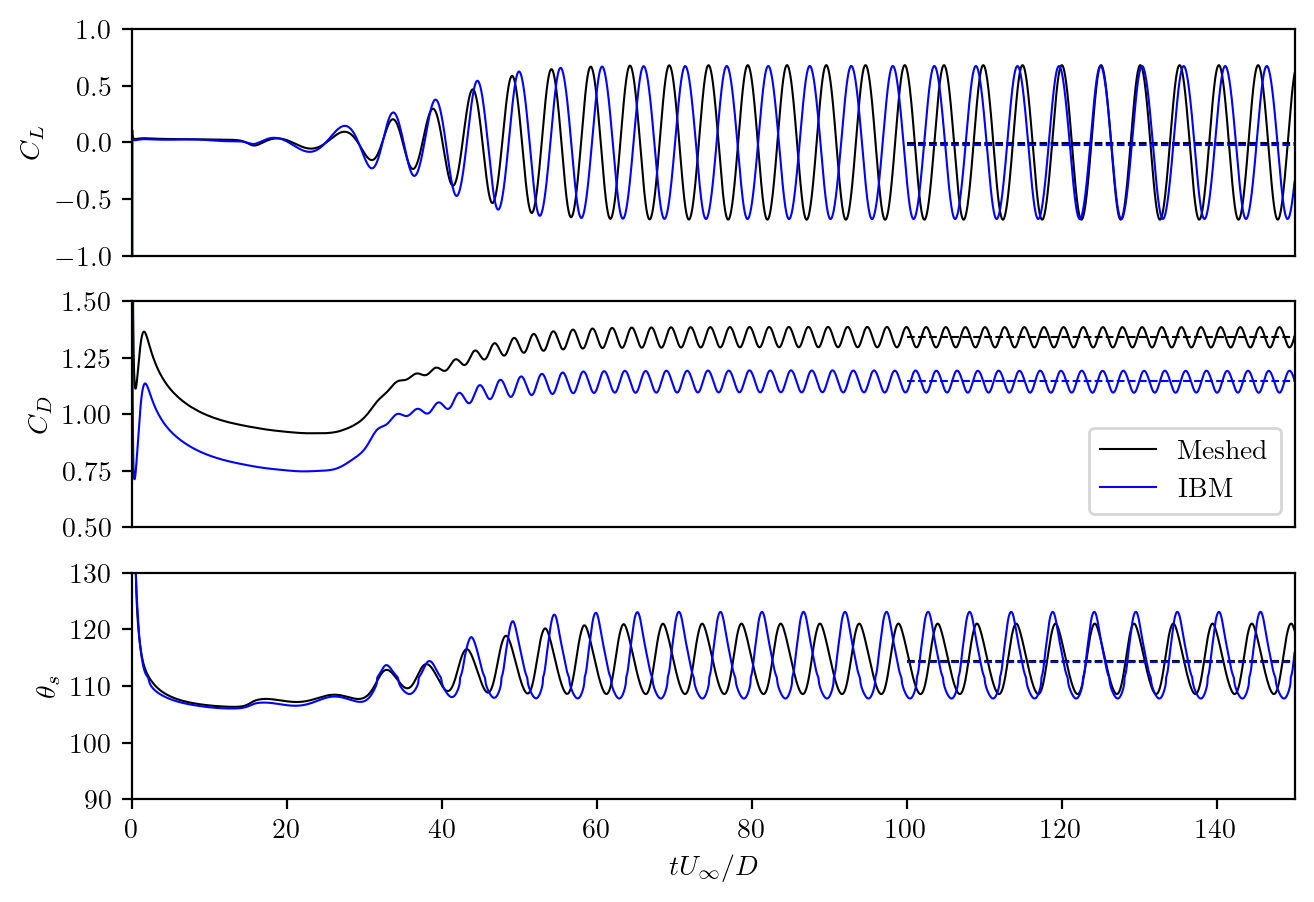

In [5]:
import matplotlib.pyplot as plt
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 0.75


fig, ax = plt.subplots(3,1, figsize=(7.5, 5), dpi = 200)
# Meshed
ax[0].plot(meshed_LD["t"], meshed_LD["fy_tot"]*2, '-k', label =  "Meshed")
ax[0].plot([100, 150], [meshed_mean_L*2, meshed_mean_L*2], '--k')
ax[1].plot(meshed_LD["t"], meshed_LD["fx_tot"]*2, '-k', label =  "Meshed")
ax[1].plot([100, 150], [meshed_mean_D*2, meshed_mean_D*2], '--k')
ax[2].plot(meshed_theta["times"], 180.0 - np.rad2deg(meshed_theta["angles"][:,0]), '-k', label =  "Meshed")
ax[2].plot([100, 150], [meshed_mean_t, meshed_mean_t], '--k')
# IBM
ax[0].plot(IBM_LD["t"], IBM_LD["fy_tot"]*2, '-b', label =  "IBM")
ax[0].plot([100, 150], [IBM_mean_L*2, IBM_mean_L*2], '--b')
ax[1].plot(IBM_LD["t"], IBM_LD["fx_tot"]*2, '-b', label =  "IBM")
ax[1].plot([100, 150], [IBM_mean_D*2, IBM_mean_D*2], '--b')
ax[2].plot(IBM_theta["times"], 180.0 - np.rad2deg(IBM_theta["angles"][:,0]), '-b', label =  "IBM")
ax[2].plot(IBM_theta["times"], 180.0 - np.rad2deg(IBM_theta["angles"][:,1]), '-b', label =  "IBM")
ax[2].plot(IBM_theta["times"], 180.0 - np.rad2deg(IBM_theta["angles"][:,2]), '-b', label =  "IBM")
ax[2].plot([100, 150], [IBM_mean_t, IBM_mean_t], '--b')

                                       
ax[0].set_ylabel("$C_L$")                                                    
ax[1].set_ylabel("$C_D$")                                                    
ax[0].set_ylim([-1, 1])                                                   
ax[1].set_ylim([0.5, 1.5])   
ax[2].set_ylim([90, 130])

ax[0].set_xlim([0, 150])      
ax[1].set_xlim([0, 150])  
ax[2].set_xlim([0, 150])  

ax[0].set_xticks([])
ax[1].set_xticks([])

ax[2].set_ylabel(r"$\theta_s$")                                               
ax[1].legend()                                                              
ax[2].set_xlabel(r"$t U_\infty/D$")  

fig.savefig(plots_dir + '/report_LDt.eps')


print(' Meshed & ' + f'{meshed_mean_L*2:.3f}' + ' & ' + f'{meshed_amp_L*2:.3f}'
    + ' & ' + f'{meshed_mean_D*2:.3f}' + ' & ' + f'{meshed_amp_D*2:.3f}'
    + ' & ' + f'{meshed_mean_t:.3f}' + ' & ' + f'{meshed_amp_t:.3f}'
    + ' & ' + f'{meshed_St:.3f}' + ' \\\\')
print(' IBM & ' + f'{IBM_mean_L*2:.3f}' + ' & ' + f'{IBM_amp_L*2:.3f}'
    + ' & ' + f'{IBM_mean_D*2:.3f}' + ' & ' + f'{IBM_amp_D*2:.3f}'
    + ' & ' + f'{IBM_mean_t:.3f}' + ' & ' + f'{IBM_amp_t:.3f}'
    + ' & ' + f'{IBM_St:.3f}' + ' \\\\')
print(' Difference & ' + f'{(IBM_mean_L - meshed_mean_L)/meshed_mean_L*100:.1f}' 
    + '\%  & ' + f'{(IBM_amp_L - meshed_amp_L)/meshed_amp_L*100:.1f}'
    + '\%  & ' + f'{(IBM_mean_D - meshed_mean_D)/meshed_mean_D*100:.1f}'
    + '\%  & ' + f'{(IBM_amp_D - meshed_amp_D)/meshed_amp_D*100:.1f}'
    + '\%  & ' + f'{(IBM_mean_t - meshed_mean_t)/meshed_mean_t*100:.1f}'
    + '\%  & ' + f'{(IBM_amp_t - meshed_amp_t)/meshed_amp_t*100:.1f}'
    + '\%  & ' + f'{(IBM_St - meshed_St)/meshed_St*100:.1f}'
    + '\%  \\\\')
print(' Difference & ' + f'{(IBM_mean_L - meshed_mean_L)*2:.3f}' 
    + '  & ' + f'{(IBM_amp_L - meshed_amp_L)*2:.3f}'
    + '  & ' + f'{(IBM_mean_D - meshed_mean_D)*2:.3f}'
    + '  & ' + f'{(IBM_amp_D - meshed_amp_D)*2:.3f}'
    + '  & ' + f'{(IBM_mean_t - meshed_mean_t):.3f}'
    + '  & ' + f'{(IBM_amp_t - meshed_amp_t):.3f}'
    + '  & ' + f'{(IBM_St - meshed_St):.3f}'
    + '  \\\\')

# Statistics files
I actually think the top two plots would look better with an instantious snapshot of the vorticity!

In [6]:
import os
os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
import matplotlib.pyplot as plt
import numpy as np
from pynektools.datatypes.field import FieldRegistry




stats_file = "fluid_stats0"
# stats_file = "field0"
meshed = {}
IBM = {}
meshed["name"] = 'meshed'
IBM["name"] = 'IBM'


# IBM
file_name = results_path + brinkman_path + stats_file + '/' + stats_file
IBM["mesh"], IBM["fld"] = load_stats_file(file_name, 2)

# Meshed
file_name = results_path + meshed_path + stats_file + '/' + stats_file
meshed["mesh"], meshed["fld"] = load_stats_file(file_name, 2)

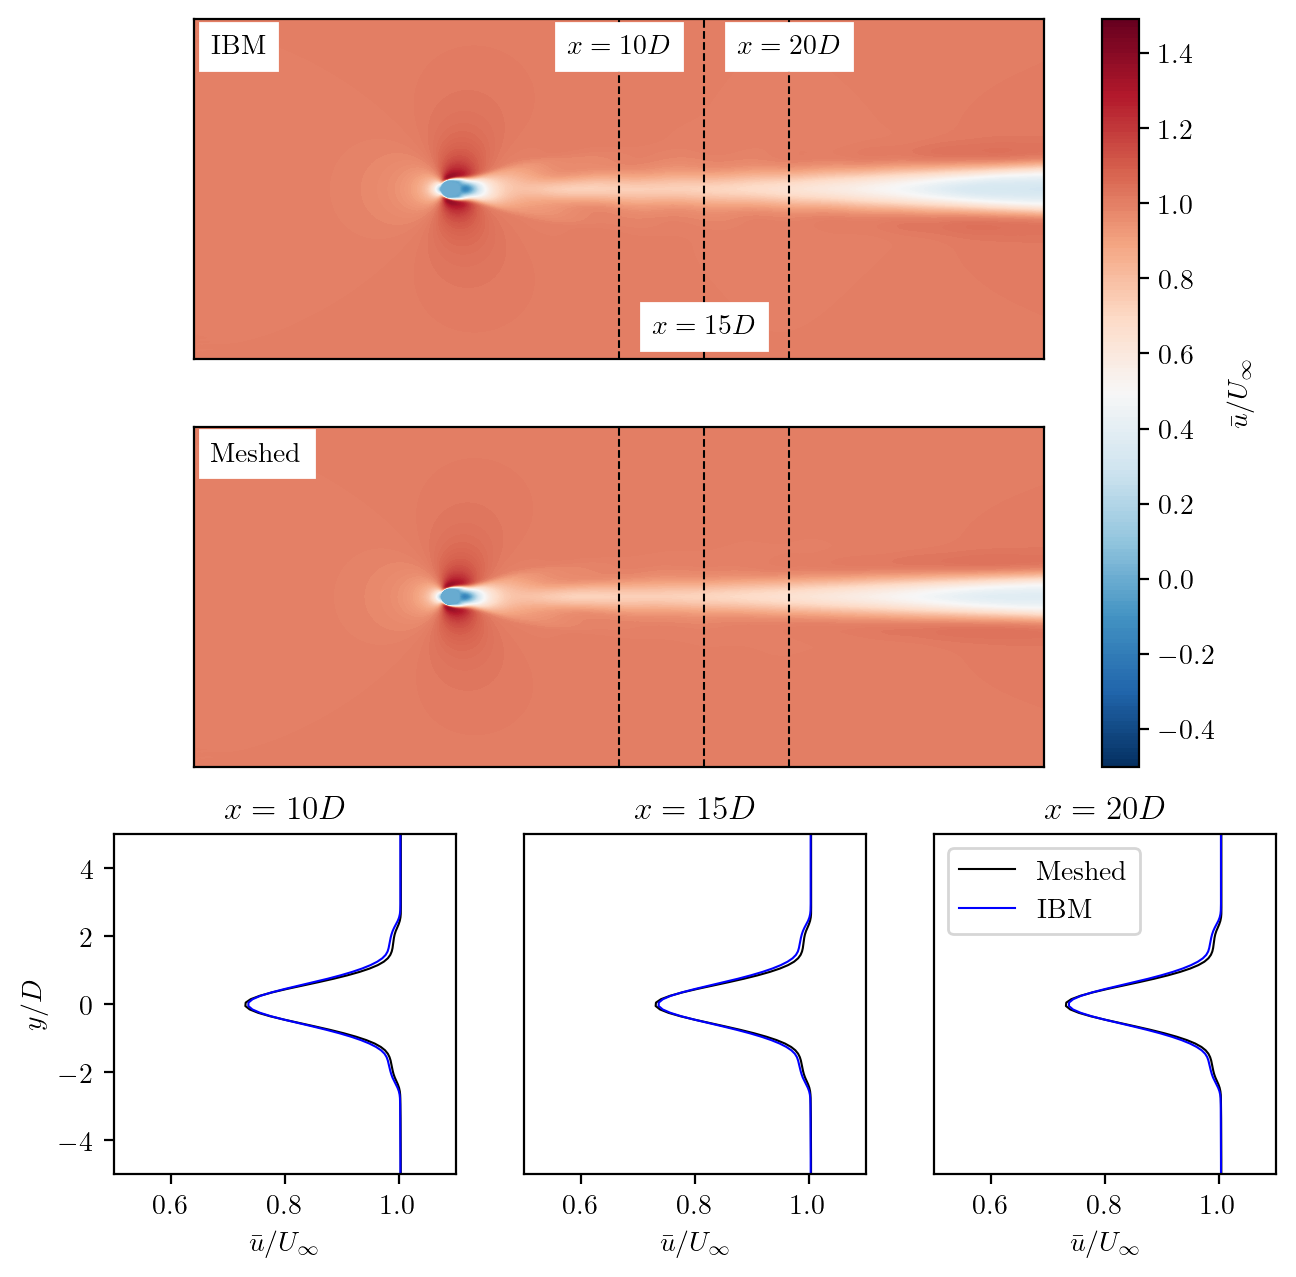

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [7]:
meshed_wake_line = wake(meshed_dir, plot_params, cache_dir)
IBM_wake_line = wake(IBM_dir, plot_params, cache_dir)

from matplotlib.gridspec import GridSpec

#constrained_layout=True
fig = plt.figure( figsize=(7.5, 7.5), dpi = 200)
gs = GridSpec(3, 3, figure=fig)

ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, :])
ax2 = fig.add_subplot(gs[2, 0])
ax3 = fig.add_subplot(gs[2, 1])
ax4 = fig.add_subplot(gs[2, 2])

c = ax0.tricontourf(IBM["mesh"].x.flatten(), IBM["mesh"].y.flatten() ,IBM["fld"].registry["u"].flatten(), levels=np.arange(start=-0.5, stop=1.5, step=0.01), cmap="RdBu_r")
cbar = fig.colorbar(c, ax = [ax0, ax1])
cbar.set_label(r'$\bar{u}/U_\infty$')
ax0.set_aspect('equal')
ax0.set_xticks([])
ax0.set_yticks([])
ax0.set_ylim([-10, 10])
ax0.plot([10, 10], [-10, 10], '--k')
ax0.text(-14, 8, "IBM",backgroundcolor='w', horizontalalignment = 'left')
ax0.text(10, 8, r"$x = 10D$",backgroundcolor='w', horizontalalignment = 'center')
ax0.text(20, 8, r"$x = 20D$",backgroundcolor='w', horizontalalignment = 'center')
ax0.text(15, -8.5, r"$x = 15D$",backgroundcolor='w', horizontalalignment = 'center')
ax0.plot([15, 15], [-10, 10], '--k')
ax0.plot([20, 20], [-10, 10], '--k')
c = ax1.tricontourf(meshed["mesh"].x.flatten(), meshed["mesh"].y.flatten() ,meshed["fld"].registry["u"].flatten(), levels=np.arange(start=-0.5, stop=1.5, step=0.01), cmap="RdBu_r")
ax1.plot([10, 10], [-10, 10], '--k')
ax1.plot([15, 15], [-10, 10], '--k')
ax1.plot([20, 20], [-10, 10], '--k')
ax1.text(-14, 8, "Meshed",backgroundcolor='w', horizontalalignment = 'left')
ax1.set_aspect('equal')
ax1.set_ylim([-10, 10])
ax1.set_xticks([])
ax1.set_yticks([]) 

wake_index = np.where(meshed_wake_line["wake_xyz"][:,0] == 10)
ax2.plot(meshed_wake_line["wake_u"][0,:].flatten(), meshed_wake_line["wake_xyz"][wake_index, 1].flatten(), '-k', label="Meshed")
ax2.plot(IBM_wake_line["wake_u"][0,:].flatten(), IBM_wake_line["wake_xyz"][wake_index, 1].flatten(),'-b', label="IBM")
wake_index = np.where(meshed_wake_line["wake_xyz"][:,0] == 15)
ax3.plot(meshed_wake_line["wake_u"][0,:].flatten(), meshed_wake_line["wake_xyz"][wake_index, 1].flatten(), '-k', label="Meshed")
ax3.plot(IBM_wake_line["wake_u"][0,:].flatten(), IBM_wake_line["wake_xyz"][wake_index, 1].flatten(),'-b', label="IBM")
wake_index = np.where(meshed_wake_line["wake_xyz"][:,0] == 20)
ax4.plot(meshed_wake_line["wake_u"][0,:].flatten(), meshed_wake_line["wake_xyz"][wake_index, 1].flatten(), '-k', label="Meshed")
ax4.plot(IBM_wake_line["wake_u"][0,:].flatten(), IBM_wake_line["wake_xyz"][wake_index, 1].flatten(),'-b', label="IBM")


ax2.set_xlim([0.5, 1.1])
ax3.set_xlim([0.5, 1.1])
ax4.set_xlim([0.5, 1.1])
ax2.set_ylim([-5, 5])
ax3.set_ylim([-5, 5])
ax4.set_ylim([-5, 5])

ax3.set_yticks([])
ax4.set_yticks([])

ax2.set_title(r'$x = 10D$')
ax3.set_title(r'$x = 15D$')
ax4.set_title(r'$x = 20D$')

ax2.set_xlabel(r"$\bar{u}/U_\infty$") 
ax2.set_ylabel(r"$y/D$")
ax3.set_xlabel(r"$\bar{u}/U_\infty$")
ax4.set_xlabel(r"$\bar{u}/U_\infty$")
ax4.legend()  


plt.show()

fig.savefig(plots_dir + '/report_wake_deficit.png')
fig.savefig(plots_dir + '/report_wake_deficit.eps')

Ok this one didn't make it into the post processing script so there's no cache for this

In [8]:
def calculate_forces(msh, fld, ring_radii, n_points, Re):
    from mpi4py import MPI #equivalent to the use of MPI_init() in C
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry

    # Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
    import os
    os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
    
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry
    from pynektools.postprocessing.file_indexing import index_files_from_folder

    from pynektools.interpolation.probes import Probes
    import pynektools.interpolation.utils as interp_utils
    import pynektools.interpolation.pointclouds as pcs

    # Get mpi info
    comm = MPI.COMM_WORLD
    
    # compute derivatives
    coef = Coef(msh, comm, get_area=False)
    dudx = coef.dudxyz(fld.registry['u'], coef.drdx, coef.dsdx, coef.dtdx)
    dudy = coef.dudxyz(fld.registry['u'], coef.drdy, coef.dsdy, coef.dtdx)
    dvdx = coef.dudxyz(fld.registry['v'], coef.drdx, coef.dsdx, coef.dtdx)
    dvdy = coef.dudxyz(fld.registry['v'], coef.drdy, coef.dsdy, coef.dtdx)

    # It's probably best to take a good z location so we don't get fucked interpolation between z coords
    z_GLL = np.unique(msh.z)

    # set up probes
    if comm.Get_rank() == 0 :
    
        # Generate the 1D mesh
        r_1d = np.array(ring_radii)
        th_1d = pcs.generate_1d_arrays([0, 2*np.pi], n_points, mode="equal")
        z_1d = np.array([z_GLL[2]])
    
        # Generate a 3D mesh
        r, th, z = np.meshgrid(r_1d, th_1d, z_1d, indexing='ij')
        x = r*np.cos(th)
        y = r*np.sin(th)
    
        # Array the points as a list of probes
        xyz = interp_utils.transform_from_array_to_list(len(ring_radii),n_points,1,[x, y, z])
    
    else:
        xyz = None
    
    
    # This sets up the probes interpolation
    ring_probes = Probes(comm, probes = xyz, msh = msh, point_interpolator_type='multiple_point_legendre_numpy', \
                             max_pts=256, find_points_comm_pattern='point_to_point')
    
    # here we actually probe
    ring_probes.interpolate_from_field_list(0, [dudx], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dudx = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dudy], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dudy = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dvdx], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dvdx = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dvdy], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dvdy = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [fld.registry['p']], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    p = np.copy(int_fields[1])

    ring_probes.interpolate_from_field_list(0, [fld.registry['t']], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    pp = np.copy(int_fields[1])
    
    f_x_visc = np.zeros((len(ring_radii), n_points))
    f_y_visc = np.zeros((len(ring_radii), n_points))
    f_x_p    = np.zeros((len(ring_radii), n_points))
    f_y_p    = np.zeros((len(ring_radii), n_points))
    f_x_tot  = np.zeros((len(ring_radii), n_points))
    f_y_tot  = np.zeros((len(ring_radii), n_points))
    p_rms    = np.zeros((len(ring_radii), n_points))
    
    f_x_visc_int = np.zeros((len(ring_radii)))
    f_y_visc_int = np.zeros((len(ring_radii)))
    f_x_p_int    = np.zeros((len(ring_radii)))
    f_y_p_int    = np.zeros((len(ring_radii)))
    f_x_tot_int  = np.zeros((len(ring_radii)))
    f_y_tot_int  = np.zeros((len(ring_radii)))
    
    for i in range(len(ring_radii)):
        for j in range(n_points):
            # viscous
            f_x_visc[i,j] = ( dudx[i,j] * 2          * np.cos(th_1d[j]) + 
                             (dudy[i,j] + dvdx[i,j]) * np.sin(th_1d[j]))/Re
            f_y_visc[i,j] = ((dudy[i,j] + dvdx[i,j]) * np.cos(th_1d[j]) + 
                              dvdy[i,j] * 2          * np.sin(th_1d[j]))/Re
            
            #pressure
            f_x_p[i,j] = -p[i,j] * np.cos(th_1d[j])
            f_y_p[i,j] = -p[i,j] * np.sin(th_1d[j])

            # total
            f_x_tot[i,j] = f_x_visc[i,j] + f_x_p[i,j]
            f_y_tot[i,j] = f_y_visc[i,j] + f_y_p[i,j]

            # p rms
            p_rms[i,j] = np.sqrt(np.abs(pp[i,j] - p[i,j]*p[i,j]))
        

    # Here we integrate them around to get a single number
    for i in range(len(ring_radii)):
        ri1 = (n_points)*i
        ri2 = (n_points )*(i+1)
        dS = (2 * np.pi * ring_radii[i]) / n_points
        
        f_x_visc_int[i] = np.sum(f_x_visc[i,:]) * dS
        f_y_visc_int[i] = np.sum(f_y_visc[i,:]) * dS
        f_x_p_int[i]    = np.sum(f_x_p[i,:]) * dS
        f_y_p_int[i]    = np.sum(f_y_p[i,:]) * dS
        
        f_x_tot_int[i] = f_x_visc_int[i] + f_x_p_int[i]
        f_y_tot_int[i] = f_y_visc_int[i] + f_y_p_int[i]

        force_measure = {}
        force_measure["fx_tot"] = f_x_tot
        force_measure["fx_p"] = f_x_p
        force_measure["fx_visc"] = f_x_visc
        force_measure["fy_tot"] = f_y_tot
        force_measure["fy_p"] = f_y_p
        force_measure["fy_visc"] = f_y_visc
        force_measure["fx_tot_int"] = f_x_tot_int
        force_measure["fx_p_int"] = f_x_p_int
        force_measure["fx_visc_int"] = f_x_visc_int
        force_measure["fy_tot_int"] = f_y_tot_int
        force_measure["fy_p_int"] = f_y_p_int
        force_measure["fy_visc_int"] = f_y_visc_int
        force_measure["p"] = p
        force_measure["p_rms"] = p_rms
        force_measure["ring"] = ring_radii

    return force_measure

In [9]:
ring_radii = [0.50]
n_points = 360
Re = 200.0

IBM["stats_forces"] = calculate_forces(IBM["mesh"], IBM["fld"], ring_radii, n_points, Re)
meshed["stats_forces"] = calculate_forces(meshed["mesh"], meshed["fld"], ring_radii, n_points, Re)
case_list = [IBM, meshed]



/tmp/user/12792/ipykernel_2454952/2768590022.py:102: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_x_visc[i,j] = ( dudx[i,j] * 2          * np.cos(th_1d[j]) +
/tmp/user/12792/ipykernel_2454952/2768590022.py:104: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_y_visc[i,j] = ((dudy[i,j] + dvdx[i,j]) * np.cos(th_1d[j]) +
/tmp/user/12792/ipykernel_2454952/2768590022.py:108: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_x_p[i,j] = -p[i,j] * np.cos(th_1d[j])
/tmp/use

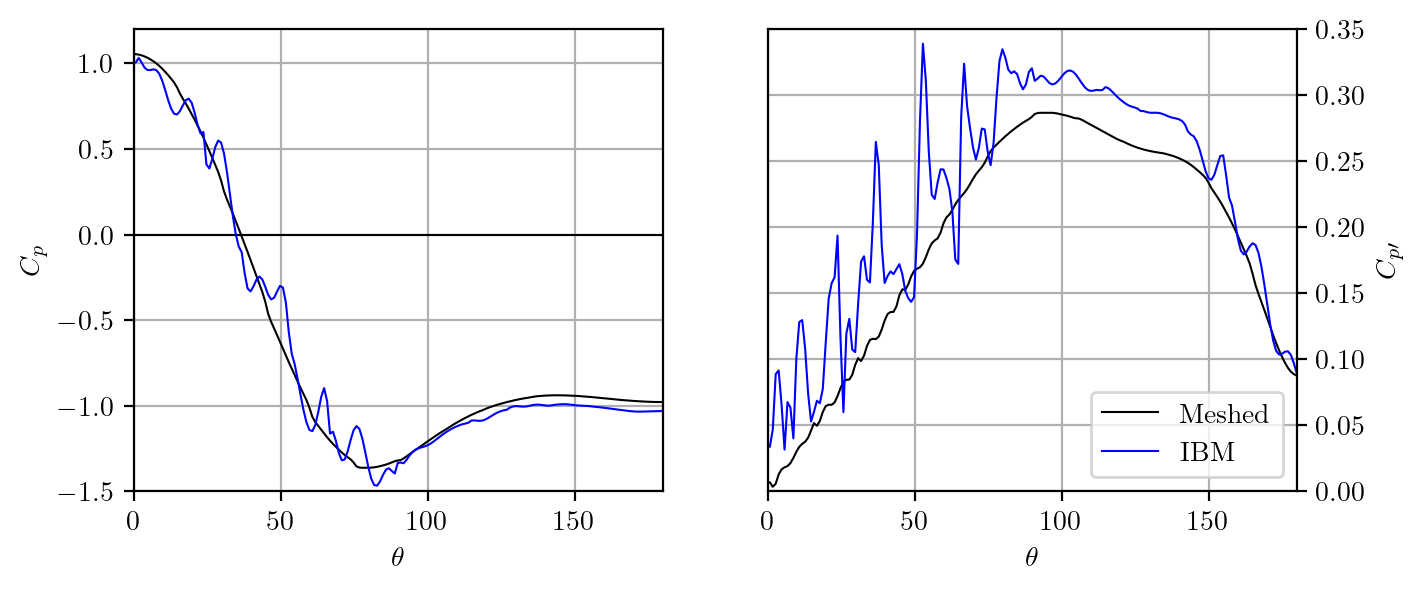

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [10]:
import pynektools.interpolation.pointclouds as pcs
th_1d = pcs.generate_1d_arrays([0, 2*np.pi], n_points, mode="equal") 

fig, ax = plt.subplots(1, 2, figsize=(7.5, 3), dpi = 200)
ring_index = np.where(np.array(meshed["stats_forces"]["ring"]) == 0.50)

meshed_Cp = meshed["stats_forces"]["p"][ring_index,:].flatten()*2
IBM_Cp = IBM["stats_forces"]["p"][ring_index,:].flatten()*2
ax[0].plot([0,180], [0,0],'-k')
ax[0].plot(th_1d/np.pi*180 -180, meshed_Cp,'-k', label="Meshed")
ax[0].plot(th_1d/np.pi*180 -180, IBM_Cp,'-b', label="IBM")
ax[0].set_xlabel(r'$\theta$')
ax[0].set_ylabel(r'$C_p$')
ax[0].set_xlim([0, 180])
ax[0].set_ylim([-1.5, 1.2])
ax[0].grid()

meshed_Cp = meshed["stats_forces"]["p_rms"][ring_index,:].flatten()*2
IBM_Cp = IBM["stats_forces"]["p_rms"][ring_index,:].flatten()*2
ax[1].plot(th_1d/np.pi*180 -180, meshed_Cp,'-k', label="Meshed")
ax[1].plot(th_1d/np.pi*180 -180, IBM_Cp,'-b', label="IBM")
ax[1].set_xlabel(r'$\theta$')
ax[1].set_ylabel(r'$C_{p\prime}$')
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")
ax[1].legend()
ax[1].set_xlim([0, 180])
ax[1].set_ylim([0, 0.35])
ax[1].grid()

plt.show()

fig.savefig(plots_dir + '/report_avg_p_dist.eps')
fig.savefig(plots_dir + '/report_avg_p_dist.png')


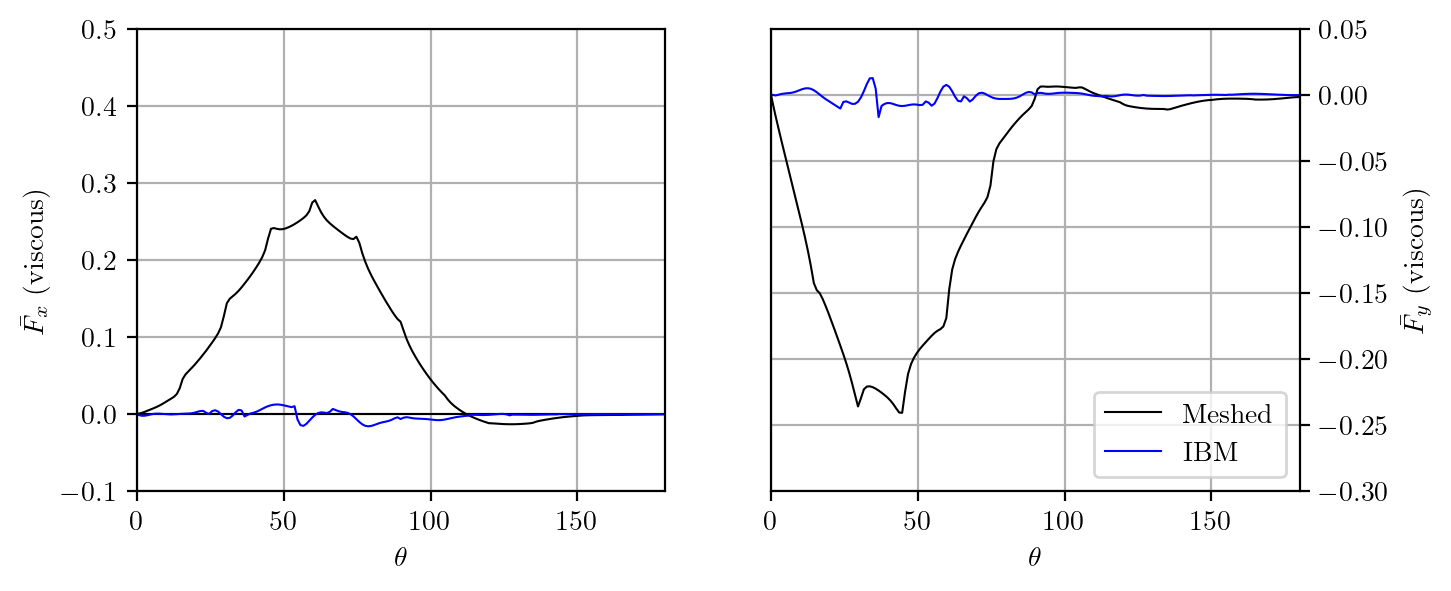

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [11]:
import pynektools.interpolation.pointclouds as pcs
th_1d = pcs.generate_1d_arrays([0, 2*np.pi], n_points, mode="equal") 

fig, ax = plt.subplots(1, 2, figsize=(7.5, 3), dpi = 200)
ring_index = np.where(np.array(meshed["stats_forces"]["ring"]) == 0.50)

meshed_Cp = meshed["stats_forces"]["fx_visc"][ring_index,:].flatten()*2
IBM_Cp = IBM["stats_forces"]["fx_visc"][ring_index,:].flatten()*2
ax[0].plot([0,180], [0,0],'-k')
ax[0].plot(th_1d/np.pi*180 -180, meshed_Cp,'-k', label="Meshed")
ax[0].plot(th_1d/np.pi*180 -180, IBM_Cp,'-b', label="IBM")
ax[0].set_xlabel(r'$\theta$')
ax[0].set_ylabel(r'$\bar{F_x}$ (viscous)')
ax[0].set_xlim([0, 180])
ax[0].set_ylim([-0.1, 0.5])
ax[0].grid()

meshed_Cp = meshed["stats_forces"]["fy_visc"][ring_index,:].flatten()*2
IBM_Cp = IBM["stats_forces"]["fy_visc"][ring_index,:].flatten()*2
ax[1].plot(th_1d/np.pi*180 -180, meshed_Cp,'-k', label="Meshed")
ax[1].plot(th_1d/np.pi*180 -180, IBM_Cp,'-b', label="IBM")
ax[1].set_xlabel(r'$\theta$')
ax[1].set_ylabel(r'$\bar{F_y}$ (viscous)')
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")
ax[1].legend()
ax[1].set_xlim([0, 180])
ax[1].set_ylim([-0.3, 0.05])
ax[1].grid()

plt.show()

fig.savefig(plots_dir + '/report_avg_visc.eps')
fig.savefig(plots_dir + '/report_avg_visc.png')


# wiggles in the solution field
So I guess we went with our smallest filter radius on a rather coarse mesh, so it's hard to tell if those wiggles are due to unconverged statistics or the IBM, so let's look at an interpolation of the pressure field

In [12]:
from pynektools.interpolation.probes import Probes
import pynektools.interpolation.utils as interp_utils
import pynektools.interpolation.pointclouds as pcs
# Get mpi info
comm = MPI.COMM_WORLD


square_size = 1
n_pts = 300


z_GLL = np.unique(IBM["mesh"].z)
  
# Here we set up the uniform cartesian mesh around the cylinder
limits = [-square_size, square_size]
if comm.Get_rank() == 0 :
    # Wake line
    y_1d = pcs.generate_1d_arrays(limits, n_pts, mode="equal")
    x_1d = pcs.generate_1d_arrays(limits, n_pts, mode="equal")
    z_1d = np.array([z_GLL[2]])
    x, y, z = np.meshgrid(x_1d, y_1d, z_1d, indexing='ij')
    # Write the points for future use
    xyz = interp_utils.transform_from_array_to_list(n_pts, n_pts, 1, [x, y, z])
else:
    xyz = None

# Here we set up the probes
IBM_probes = Probes(comm, probes = xyz, msh = IBM["mesh"], point_interpolator_type='multiple_point_legendre_numpy', \
                         max_pts=256, find_points_comm_pattern='point_to_point')

# Here we probe both the unfiltered and filtered design fields
IBM_probes.interpolate_from_field_list(0, [ IBM["fld"].registry['p']], comm, write_data=False) # unfiltered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,IBM_probes.interpolated_fields)
IBM_pressure = np.copy(int_fields[1])


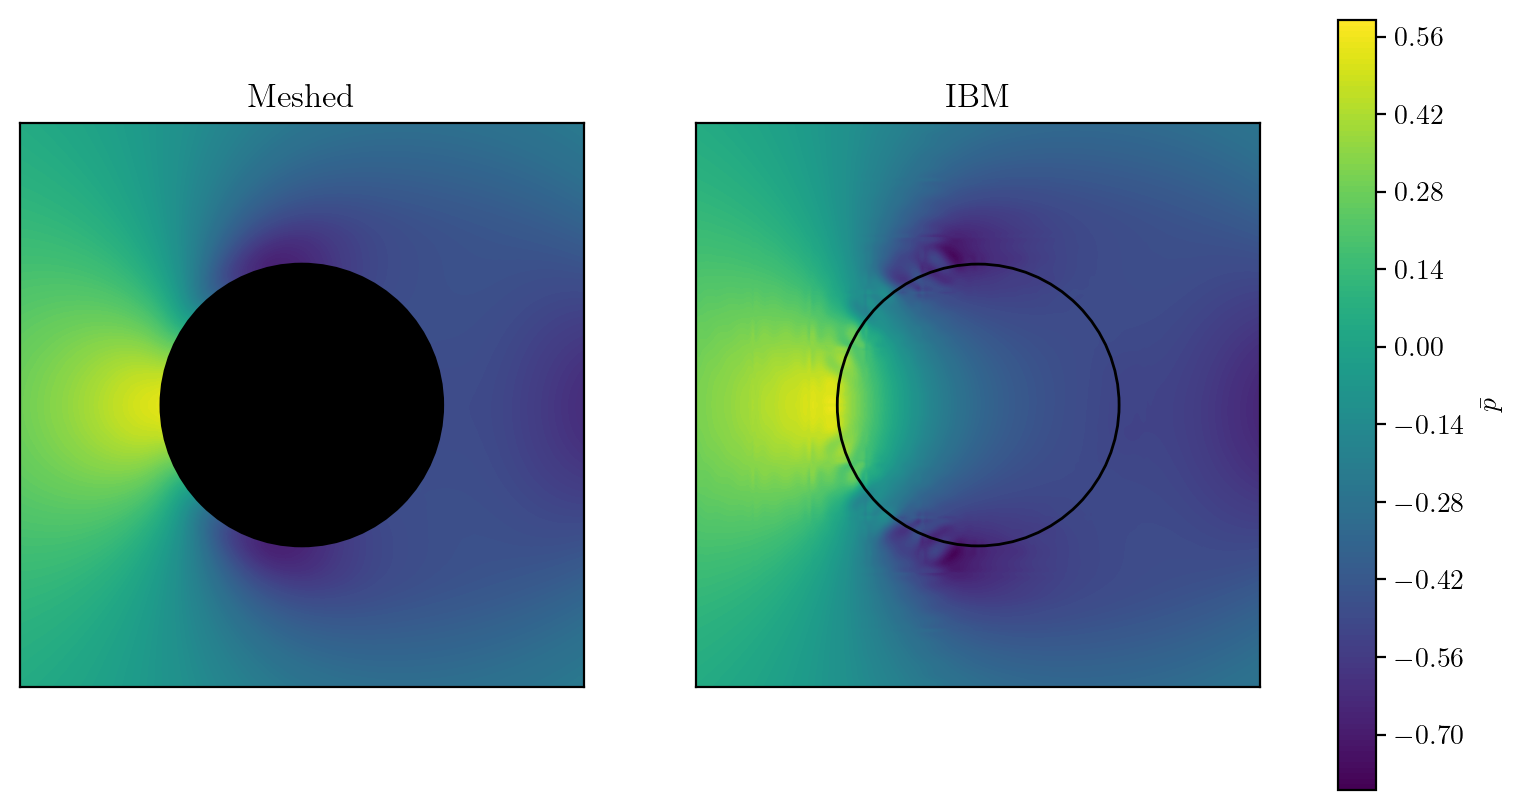

In [13]:

fig, ax = plt.subplots(1,2, figsize=(10, 5), dpi = 200)

z_GLL = np.unique(meshed["mesh"].z)
z_plane_index = np.where(meshed["mesh"].z == z_GLL[2])

circle_fill = plt.Circle((0, 0), 0.5, color='k', fill=True)
circle_nofill = plt.Circle((0, 0), 0.5, color='k', fill=False)

# plot the linearly interpolated plane
c = ax[0].tricontourf(meshed["mesh"].x[z_plane_index].flatten(), meshed["mesh"].y[z_plane_index].flatten() , \
                      meshed["fld"].registry["p"][z_plane_index].flatten(), levels=np.arange(start=-0.8, stop=0.6, step=0.01))
ax[0].add_patch(circle_fill)
ax[0].set_aspect('equal')
ax[0].set_xlim(limits)
ax[0].set_ylim(limits)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Meshed')

# plot the spectrally interpolated plane
c = ax[1].tricontourf(x.flatten(), y.flatten() ,IBM_pressure.flatten(), levels=np.arange(start=-0.8, stop=0.6, step=0.01))
ax[1].add_patch(circle_nofill)
cbar = fig.colorbar(c, ax = ax[:])
cbar.set_label(r'$\bar{p}$')
ax[1].set_aspect('equal')
ax[1].set_xlim(limits)
ax[1].set_ylim(limits)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('IBM')

plt.show()

fig.savefig(plots_dir + '/pressure_distribution.png')

# Viscous stresses
I guess the last thing in terms of trying to blame the viscous stresses is to plot them.

In [14]:
def get_gradients(msh, fld):
    from mpi4py import MPI #equivalent to the use of MPI_init() in C
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry

    # Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
    import os
    os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
    
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry
    from pynektools.postprocessing.file_indexing import index_files_from_folder

    from pynektools.interpolation.probes import Probes
    import pynektools.interpolation.utils as interp_utils
    import pynektools.interpolation.pointclouds as pcs

    # Get mpi info
    comm = MPI.COMM_WORLD
    
    # compute derivatives
    coef = Coef(msh, comm, get_area=False)
    dudx = coef.dudxyz(fld.registry['u'], coef.drdx, coef.dsdx, coef.dtdx)
    dudy = coef.dudxyz(fld.registry['u'], coef.drdy, coef.dsdy, coef.dtdx)
    dvdx = coef.dudxyz(fld.registry['v'], coef.drdx, coef.dsdx, coef.dtdx)
    dvdy = coef.dudxyz(fld.registry['v'], coef.drdy, coef.dsdy, coef.dtdx)

    return dudx, dudy, dvdx, dvdy

    

In [15]:
IBM_dudx_fld, IBM_dudy_fld, IBM_dvdx_fld, IBM_dvdy_fld = get_gradients(IBM["mesh"], IBM["fld"])
mesh_dudx, mesh_dudy, mesh_dvdx, mesh_dvdy = get_gradients(meshed["mesh"], meshed["fld"])

# 
IBM_probes.interpolate_from_field_list(0, [IBM_dudx_fld], comm, write_data=False) # unfiltered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,IBM_probes.interpolated_fields)
IBM_dudx = np.copy(int_fields[1])
# 
IBM_probes.interpolate_from_field_list(0, [IBM_dudy_fld], comm, write_data=False) # unfiltered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,IBM_probes.interpolated_fields)
IBM_dudy = np.copy(int_fields[1])
# 
IBM_probes.interpolate_from_field_list(0, [IBM_dvdx_fld], comm, write_data=False) # unfiltered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,IBM_probes.interpolated_fields)
IBM_dvdx = np.copy(int_fields[1])
# 
IBM_probes.interpolate_from_field_list(0, [IBM_dvdy_fld], comm, write_data=False) # unfiltered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,IBM_probes.interpolated_fields)
IBM_dvdy = np.copy(int_fields[1])

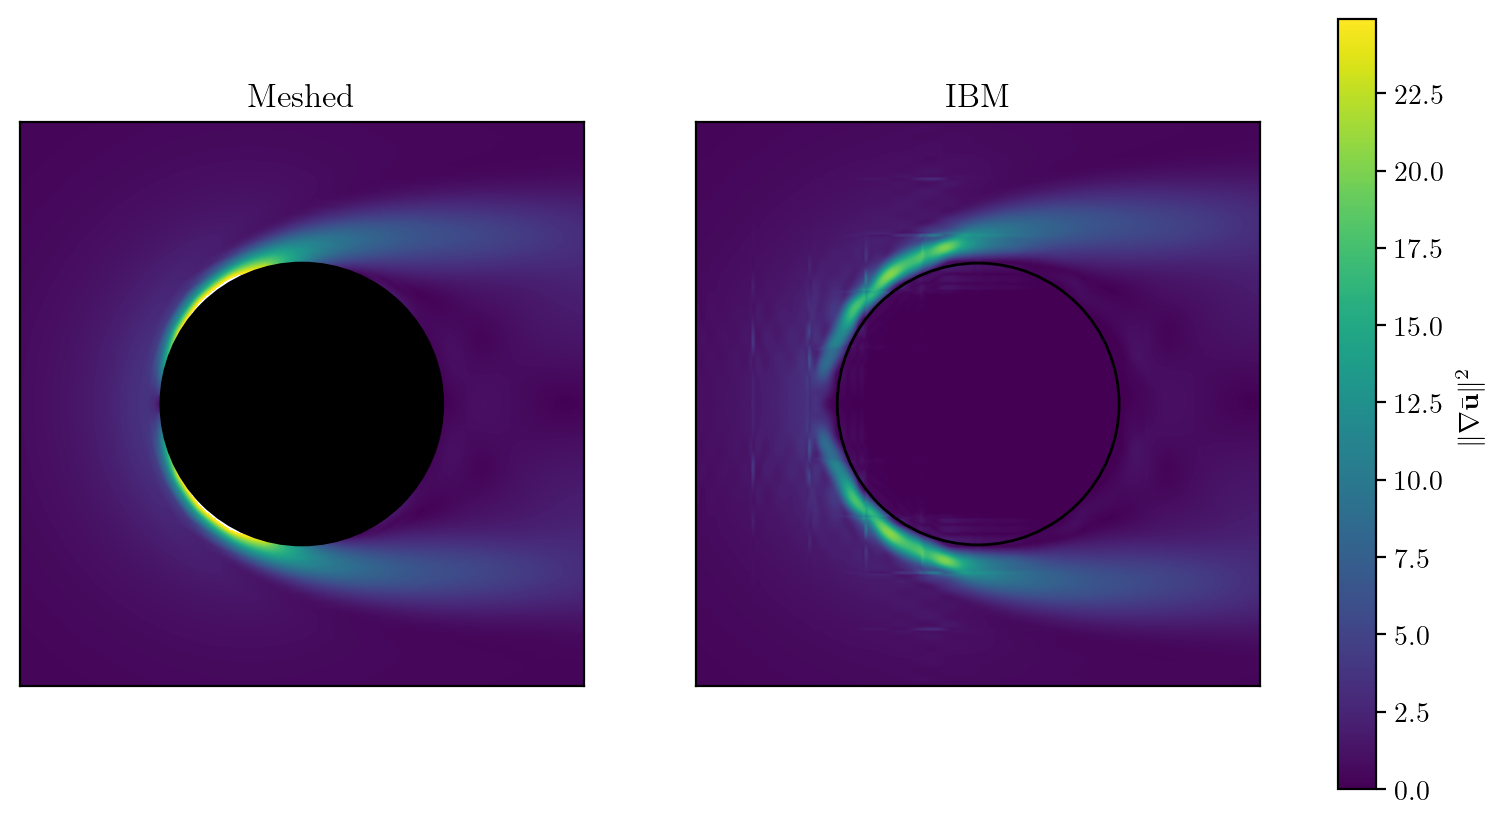

In [16]:
fig, ax = plt.subplots(1,2, figsize=(10, 5), dpi = 200)

circle_fill = plt.Circle((0, 0), 0.5, color='k', fill=True)
circle_nofill = plt.Circle((0, 0), 0.5, color='k', fill=False)

# plot the linearly interpolated plane
c = ax[0].tricontourf(meshed["mesh"].x[z_plane_index].flatten(), meshed["mesh"].y[z_plane_index].flatten() , 
                      np.sqrt(np.abs(mesh_dudx[z_plane_index].flatten()**2 + 
                                     mesh_dudy[z_plane_index].flatten()**2 + 
                                     mesh_dvdx[z_plane_index].flatten()**2 + 
                                     mesh_dvdy[z_plane_index].flatten()**2 
                                    )), levels=np.arange(start=0, stop=25, step=0.1)
                      )
ax[0].add_patch(circle_fill)
ax[0].set_aspect('equal')
ax[0].set_xlim(limits)
ax[0].set_ylim(limits)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Meshed')

# plot the spectrally interpolated plane
c = ax[1].tricontourf(x.flatten(), y.flatten() ,np.sqrt(np.abs(IBM_dudx.flatten()**2 +
                                                               IBM_dudy.flatten()**2 +
                                                               IBM_dvdx.flatten()**2 +
                                                               IBM_dvdy.flatten()**2 
                                                              )), levels=np.arange(start=0, stop=25, step=0.1)
                     )
ax[1].add_patch(circle_nofill)
cbar = fig.colorbar(c, ax = ax[:])
cbar.set_label(r'$\|\nabla \bar{\mathbf{u}}\|^2$')
ax[1].set_aspect('equal')
ax[1].set_xlim(limits)
ax[1].set_ylim(limits)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('IBM')
plt.show()

fig.savefig(plots_dir + '/gradu.png')

# Reynolds stresses
I suppose another metric to add would be locations of peak Reynolds stresses. But again, we have already put too much time into this parametric study so I don't really want to persue this.

In [17]:
from pynektools.interpolation.probes import Probes
import pynektools.interpolation.utils as interp_utils
import pynektools.interpolation.pointclouds as pcs
# Get mpi info
comm = MPI.COMM_WORLD



# Here we probe both the unfiltered and filtered design fields
IBM_probes.interpolate_from_field_list(0, [ IBM["fld"].registry['s0']], comm, write_data=False) # unfiltered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,IBM_probes.interpolated_fields)
IBM_uu = np.copy(int_fields[1])

# Here we probe both the unfiltered and filtered design fields
IBM_probes.interpolate_from_field_list(0, [ IBM["fld"].registry['s1']], comm, write_data=False) # unfiltered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,IBM_probes.interpolated_fields)
IBM_vv = np.copy(int_fields[1])

# Here we probe both the unfiltered and filtered design fields
IBM_probes.interpolate_from_field_list(0, [ IBM["fld"].registry['s3']], comm, write_data=False) # unfiltered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,IBM_probes.interpolated_fields)
IBM_uv = np.copy(int_fields[1])

# Here we probe both the unfiltered and filtered design fields
IBM_probes.interpolate_from_field_list(0, [ IBM["fld"].registry['u']], comm, write_data=False) # unfiltered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,IBM_probes.interpolated_fields)
IBM_U = np.copy(int_fields[1])

# Here we probe both the unfiltered and filtered design fields
IBM_probes.interpolate_from_field_list(0, [ IBM["fld"].registry['v']], comm, write_data=False) # unfiltered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,IBM_probes.interpolated_fields)
IBM_V = np.copy(int_fields[1])



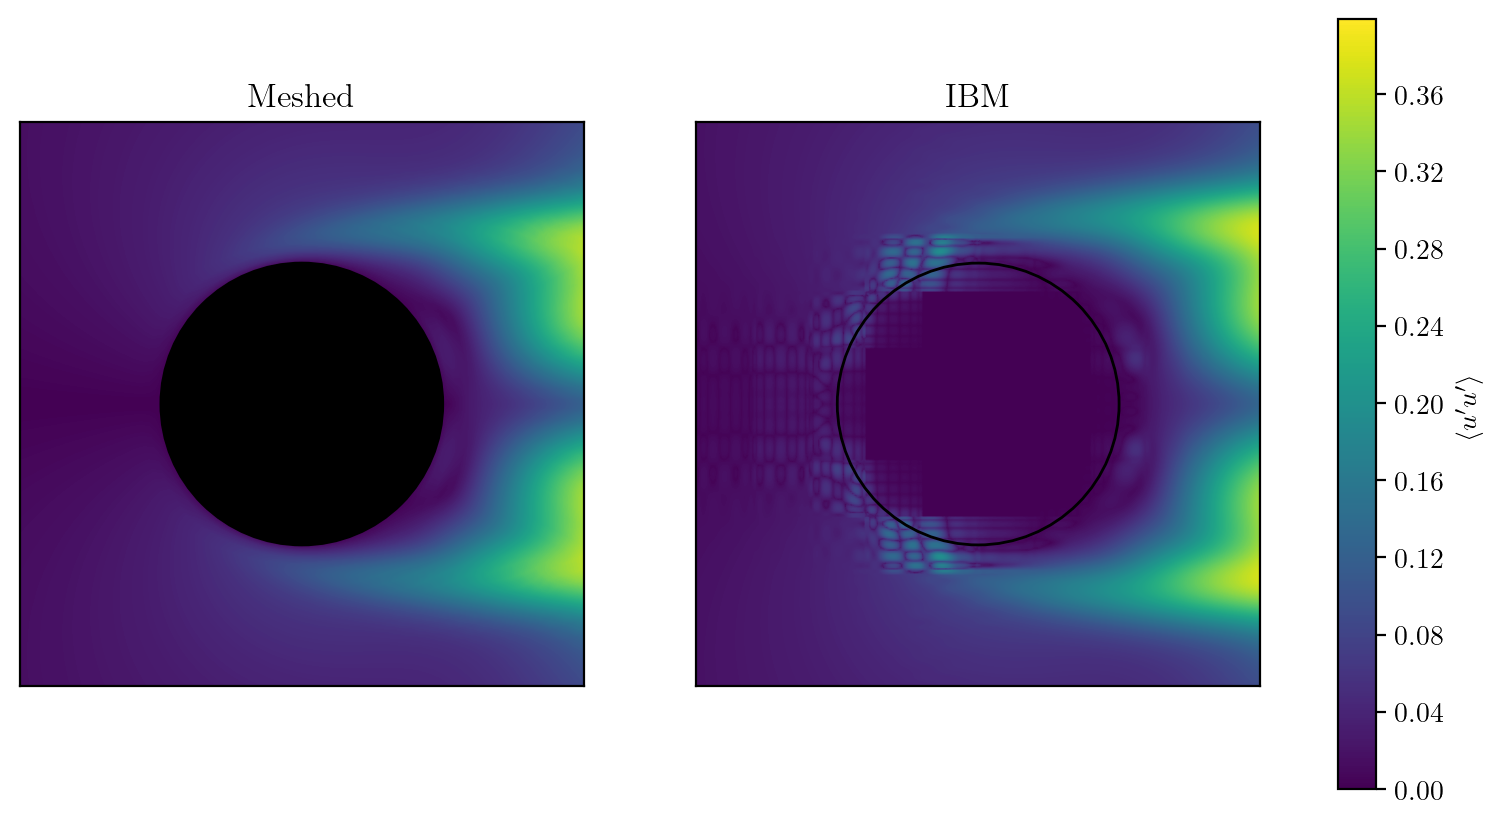

In [18]:
fig, ax = plt.subplots(1,2, figsize=(10, 5), dpi = 200)

circle_fill = plt.Circle((0, 0), 0.5, color='k', fill=True)
circle_nofill = plt.Circle((0, 0), 0.5, color='k', fill=False)

# plot the linearly interpolated plane
c = ax[0].tricontourf(meshed["mesh"].x[z_plane_index].flatten(), meshed["mesh"].y[z_plane_index].flatten() , 
                      np.sqrt(np.abs(meshed["fld"].registry["s0"][z_plane_index].flatten() - meshed["fld"].registry["u"][z_plane_index].flatten()**2)), 
                      levels=np.arange(start=0, stop=0.4, step=0.001))
ax[0].add_patch(circle_fill)
ax[0].set_aspect('equal')
ax[0].set_xlim(limits)
ax[0].set_ylim(limits)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Meshed')

# plot the spectrally interpolated plane
c = ax[1].tricontourf(x.flatten(), y.flatten() ,np.sqrt(np.abs(IBM_uu.flatten() - IBM_U.flatten()**2)),levels=np.arange(start=0, stop=0.4, step=0.001))
ax[1].add_patch(circle_nofill)
cbar = fig.colorbar(c, ax = ax[:])
cbar.set_label(r'$\langle u^\prime u^\prime \rangle$')
ax[1].set_aspect('equal')
ax[1].set_xlim(limits)
ax[1].set_ylim(limits)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('IBM')
plt.show()

fig.savefig(plots_dir + '/uu_distribution.png')

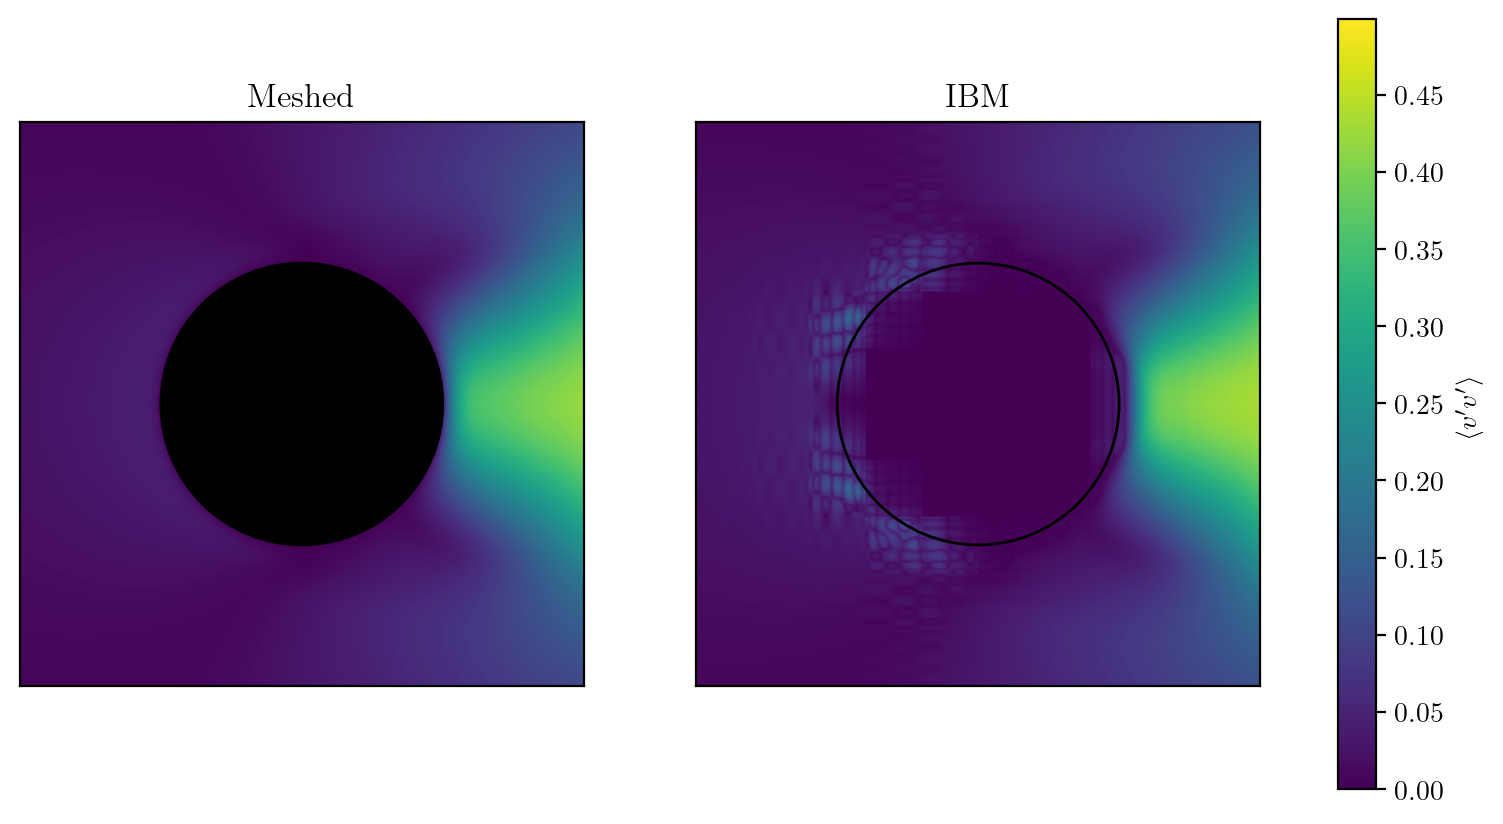

In [19]:
fig, ax = plt.subplots(1,2, figsize=(10, 5), dpi = 200)

circle_fill = plt.Circle((0, 0), 0.5, color='k', fill=True)
circle_nofill = plt.Circle((0, 0), 0.5, color='k', fill=False)

# plot the linearly interpolated plane
c = ax[0].tricontourf(meshed["mesh"].x[z_plane_index].flatten(), meshed["mesh"].y[z_plane_index].flatten() , \
                      np.sqrt(np.abs(meshed["fld"].registry["s1"][z_plane_index].flatten() - meshed["fld"].registry["v"][z_plane_index].flatten()**2))
                      , levels=np.arange(start=0, stop=0.5, step=0.001))
ax[0].add_patch(circle_fill)
ax[0].set_aspect('equal')
ax[0].set_xlim(limits)
ax[0].set_ylim(limits)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Meshed')

# plot the spectrally interpolated plane
c = ax[1].tricontourf(x.flatten(), y.flatten() ,np.sqrt(np.abs(IBM_vv.flatten() - IBM_V.flatten()**2))
                      , levels=np.arange(start=0, stop=0.5, step=0.001))
ax[1].add_patch(circle_nofill)
cbar = fig.colorbar(c, ax = ax[:])
cbar.set_label(r'$\langle v^\prime v^\prime \rangle$')
ax[1].set_aspect('equal')
ax[1].set_xlim(limits)
ax[1].set_ylim(limits)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('IBM')
plt.show()

fig.savefig(plots_dir + '/vv_distribution.png')

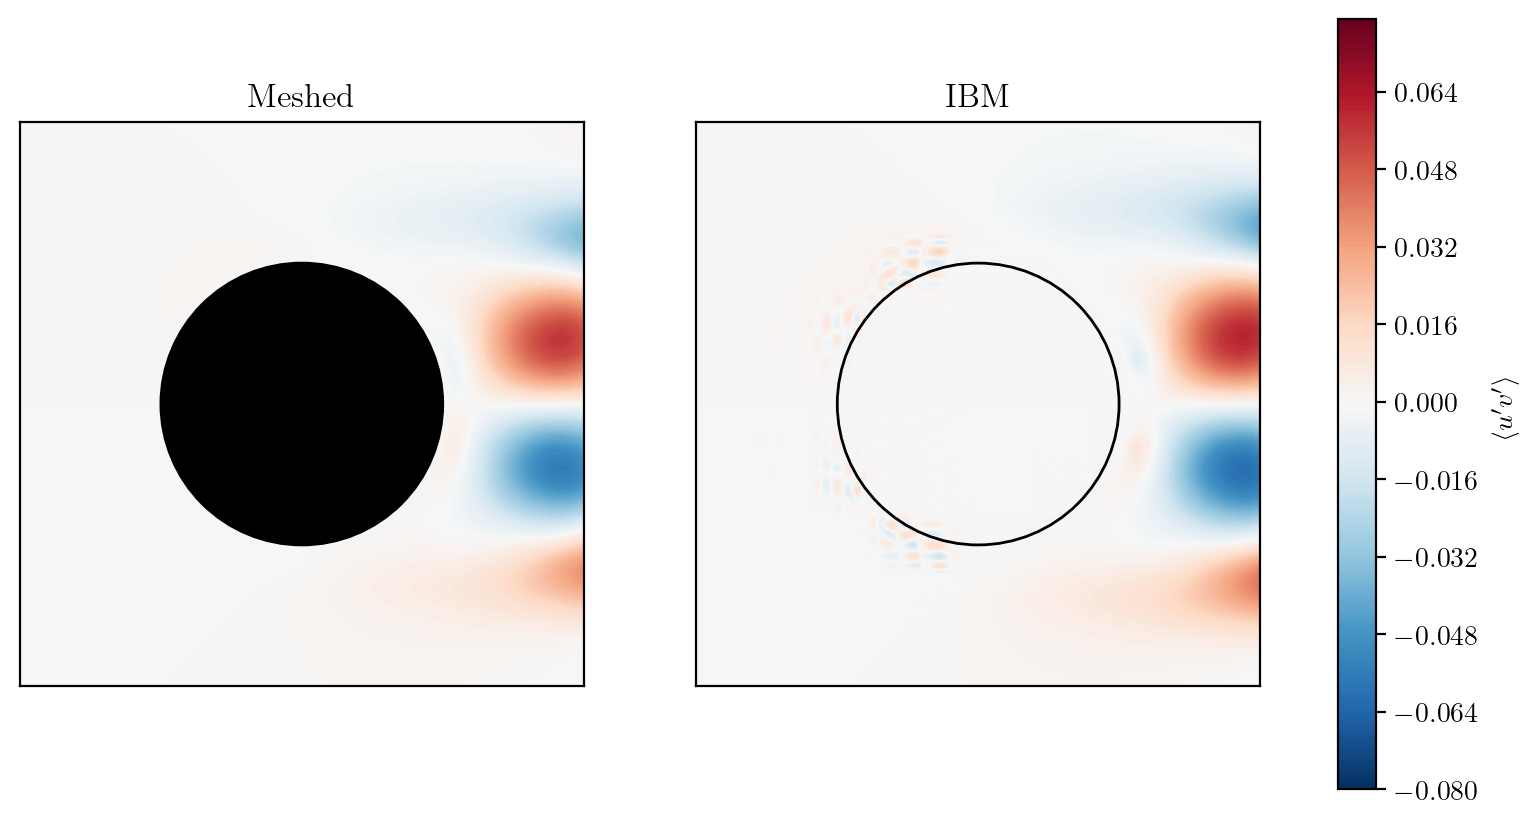

In [20]:
fig, ax = plt.subplots(1,2, figsize=(10, 5), dpi = 200)

circle_fill = plt.Circle((0, 0), 0.5, color='k', fill=True)
circle_nofill = plt.Circle((0, 0), 0.5, color='k', fill=False)

# plot the linearly interpolated plane
c = ax[0].tricontourf(meshed["mesh"].x[z_plane_index].flatten(), meshed["mesh"].y[z_plane_index].flatten() , \
                      meshed["fld"].registry["s3"][z_plane_index].flatten() - 
                                     meshed["fld"].registry["u"][z_plane_index].flatten()*meshed["fld"].registry["v"][z_plane_index].flatten()
                      ,cmap="RdBu_r", levels=np.arange(start=-0.08, stop=0.08, step=0.001))
# ,levels=np.arange(start=0, stop=0.25, step=0.001)
ax[0].add_patch(circle_fill)
ax[0].set_aspect('equal')
ax[0].set_xlim(limits)
ax[0].set_ylim(limits)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Meshed')

# plot the spectrally interpolated plane
c = ax[1].tricontourf(x.flatten(), y.flatten() ,IBM_uv.flatten() - IBM_U.flatten()*IBM_V.flatten()
                      ,cmap="RdBu_r", levels=np.arange(start=-0.08, stop=0.08, step=0.001))
#levels=np.arange(start=0, stop=0.25, step=0.001)
ax[1].add_patch(circle_nofill)
cbar = fig.colorbar(c, ax = ax[:])
cbar.set_label(r'$\langle u^\prime v^\prime \rangle$')
ax[1].set_aspect('equal')
ax[1].set_xlim(limits)
ax[1].set_ylim(limits)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('IBM')
plt.show()

fig.savefig(plots_dir + '/uv_distribution.png')